In [4]:
import seaborn as sns

# seaborn 내장 데이터 셋 불러오기 (데이터 프레임)
# https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv
df = sns.load_dataset("mpg")

# 레코드 5개만 출력해보기
#df.head()

# df.head(10) # 앞에서부터 10개 출력
# df.tail(5) #마지막 5개 출력
# df.info()
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


Help on function pairplot in module seaborn.axisgrid:

pairplot(data, *, hue=None, hue_order=None, palette=None, vars=None, x_vars=None, y_vars=None, kind='scatter', diag_kind='auto', markers=None, height=2.5, aspect=1, corner=False, dropna=False, plot_kws=None, diag_kws=None, grid_kws=None, size=None)
    Plot pairwise relationships in a dataset.
    
    By default, this function will create a grid of Axes such that each numeric
    variable in ``data`` will by shared across the y-axes across a single row and
    the x-axes across a single column. The diagonal plots are treated
    differently: a univariate distribution plot is drawn to show the marginal
    distribution of the data in each column.
    
    It is also possible to show a subset of variables or plot different
    variables on the rows and columns.
    
    This is a high-level interface for :class:`PairGrid` that is intended to
    make it easy to draw a few common styles. You should use :class:`PairGrid`
    directly 

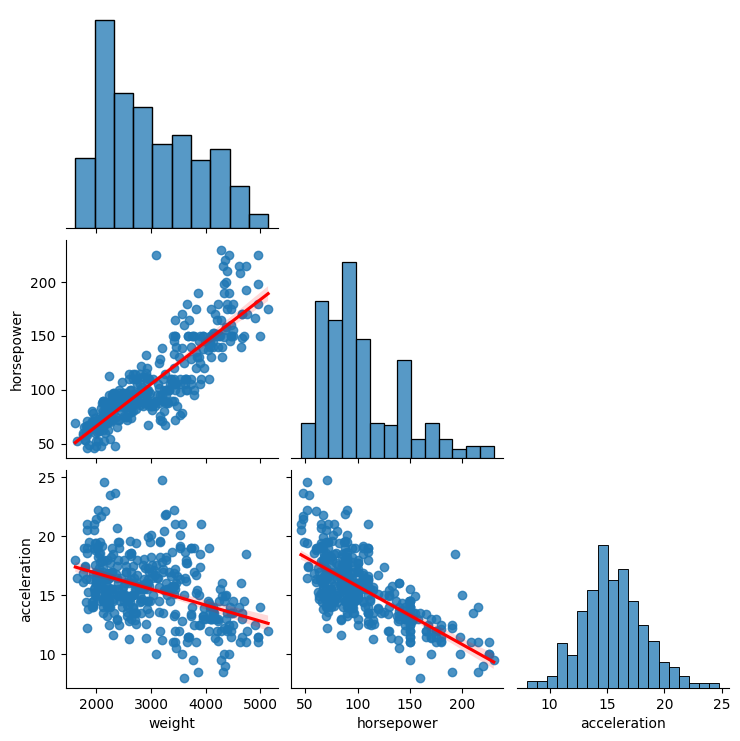

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("mpg")

# 마력에 결측치 제거 (pairplot은 결측치(NaN)값 있으면 에러 납니다.)
df = df.dropna(subset=["horsepower"]) # dropna (na는 not available): 결측치 제거

# pairplot 시각화
help(sns.pairplot)
sns.pairplot(df[["weight", "horsepower", "acceleration"]], corner=True, kind="reg", plot_kws={'line_kws': {'color': 'red'}})
print()

In [7]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# 데이터 불러오기
df, y = load_wine(as_frame=True, return_X_y=True)
df["quality"] = y

In [9]:
# 1. 이 데이터셋에 포함된 와인의 총 샘플 수를 구해서 sample_count 변수에 담아주세요!
sample_count = df.shape[0]
assert sample_count == 178, f"총 샘플 수는 178이어야 합니다. (got {sample_count})"

# 2. 이 데이터셋에 포함된 특성(feature) 수를 구해서 feature_count 변수에 담아주세요!
feature_count = df.shape[1]
assert feature_count == 14, f"특성 수는 14이어야 합니다. (got {feature_count})"

# 3. 타깃 변수(y)는 몇 개의 클래스로 구분되는지 구해서 class_count 변수에 담아주세요!
class_count = y.nunique()
assert class_count == 3, f"클래스 개수는 3이어야 합니다. (got {class_count})"

# 4. 각 클래스별 샘플 수를 Series 형태로 구해서 class_distribution 변수에 담아주세요!
class_distribution = y.value_counts()
expected_distribution = pd.Series({0: 59, 1: 71, 2: 48})
assert class_distribution.sort_index().equals(expected_distribution.sort_index()), \
    f"클래스 분포가 예상과 다릅니다.\nexpected:\n{expected_distribution}\ngot:\n{class_distribution}"

# 5. Alcohol 평균값이 가장 높은 클래스 번호를 구해서 top_alcohol_class 변수에 담아주세요!
top_alcohol_class = df.groupby('quality')['alcohol'].mean().idxmax()
assert top_alcohol_class == 0, f"Alcohol 평균이 가장 높은 클래스는 0입니다. (got {top_alcohol_class})"

# 6. Malic acid 특성의 평균을 구해서 malic_mean 변수에 담아주세요!
malic_mean = df['malic_acid'].mean()
assert np.isclose(malic_mean, 2.3363483146, atol=1e-3), f"Malic acid 평균이 예상과 다릅니다. (got {malic_mean})"

# 7. Malic acid 특성의 표준편차를 구해서 malic_std 변수에 담아주세요!
malic_std = df['malic_acid'].std()
assert np.isclose(malic_std, 1.1171460976, atol=1e-3), f"Malic acid 표준편차가 예상과 다릅니다. (got {malic_std})"

# 8. Color intensity가 10 이상인 샘플의 비율(%)을 구해서 high_color_ratio 변수에 담아주세요!
high_color_ratio = (df['color_intensity'] >= 10).mean() * 100
assert np.isclose(high_color_ratio, 3.93258427, atol=1e-2), f"Color intensity>=10 비율(%)이 예상과 다릅니다. (got {high_color_ratio})"

# 9. Ash 특성에서 최소값을 가진 샘플의 클래스를 구해서 min_ash_class 변수에 담아주세요!
min_ash_class = df.loc[df['ash'] == df['ash'].min(), 'quality'].iloc[0]
assert min_ash_class == 1, f"Ash 최소값을 가진 샘플의 클래스는 1입니다. (got {min_ash_class})"

   Class  Sample Count
0      0            59
1      1            71
2      2            48


In [10]:
# 클래스별 Proline 시리즈
proline_by_class = df.groupby('quality')['proline']

# 각 클래스별 최빈값
proline_modes = proline_by_class.apply(lambda x: x.mode().iloc[0])
print(proline_modes)

# 최빈값이 가장 큰 클래스
proline_peak_class = proline_modes.idxmax()
print(f"Proline 분포 피크가 가장 높은 클래스: {proline_peak_class}")

quality
0    1035.0
1     450.0
2     520.0
Name: proline, dtype: float64
Proline 분포 피크가 가장 높은 클래스: 0


In [38]:
# 10. Proline 분포에서 가장 높은 피크를 보이는 클래스 번호를 구해서 proline_peak_class 변수에 담아주세요!
proline_peak_class = df['quality'].value_counts().idxmax()
print(proline_peak_class)
assert proline_peak_class == 1, f"Proline 분포 피크가 가장 높은 클래스는 1입니다. (got {proline_peak_class})"

1


In [36]:
# 11. Magnesium 값이 상위 10%인 샘플들의 평균 Proline 값을 구해서 high_magnesium_proline_mean 변수에 담아주세요!
magnesium_threshold = df['magnesium'].quantile(0.9)
high_magnesium_proline_mean = df[df['magnesium'] >= magnesium_threshold]['proline'].mean()
assert np.isclose(high_magnesium_proline_mean, 864.75, atol=1e-2), \
    f"Magnesium 상위 10%의 평균 Proline은 약 864.75입니다. (got {high_magnesium_proline_mean})"

# 12. Alcohol과 가장 상관관계가 높은 특성 이름을 구해서 top_corr_with_alcohol 변수에 담아주세요!
# 상관관계 행렬에서 'alcohol' 열을 추출한 뒤, 본인을 제외하고 가장 큰 값을 찾습니다.
correlations = df.corr()['alcohol'].drop('alcohol')
top_corr_with_alcohol = correlations.idxmax()
assert top_corr_with_alcohol == "proline", f"Alcohol과 가장 상관 높은 특성은 'proline'입니다. (got {top_corr_with_alcohol})"
print("✅ 모든 테스트를 통과했습니다!")

✅ 모든 테스트를 통과했습니다!


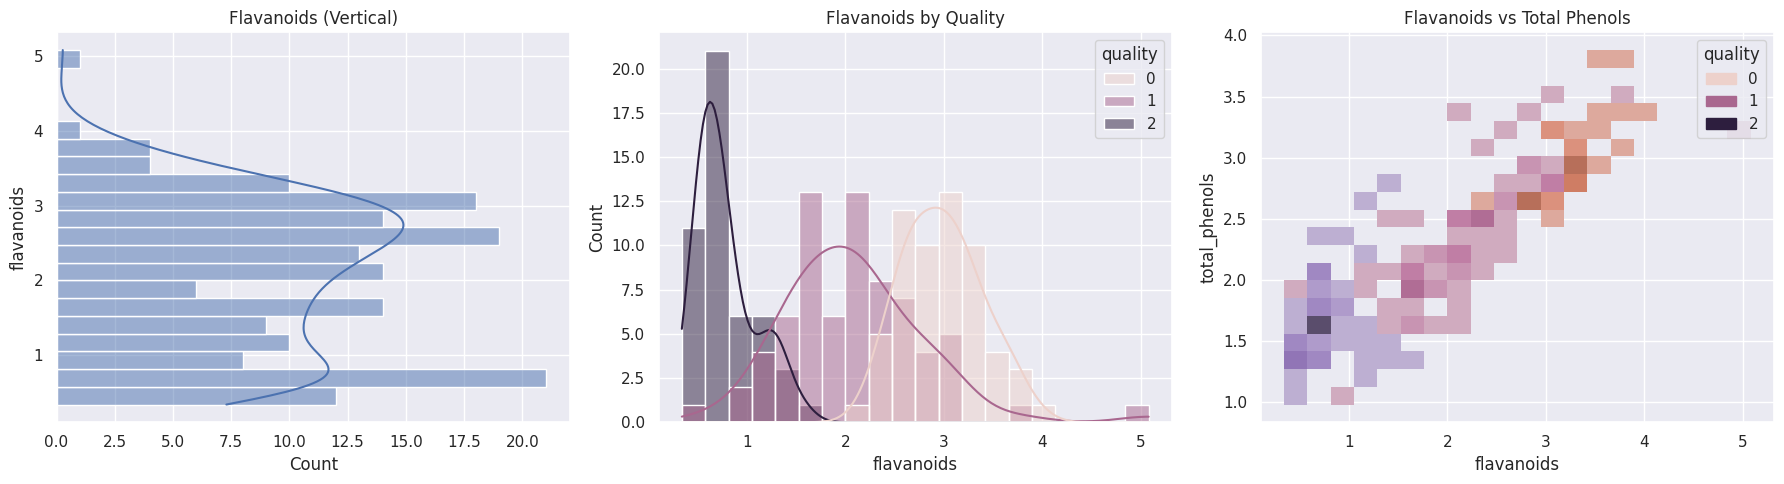

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 틀 생성
fig, ax = plt.subplots(figsize=(18, 5), ncols=3)

# 1. 위에서 그린 그림을 세로로 그리기
# x축이 아닌 y축에 변수를 할당하면 세로 방향(Horizontal bars)으로 그려집니다.
sns.histplot(y=df['flavanoids'], bins = 20, kde=True, ax=ax[0])
ax[0].set_title("Flavanoids (Vertical)")

# 2. 클래스별로 flavanoids 분포 (hue 활용)
# hue="quality"를 통해 등급별로 색상을 나누어 분포를 비교합니다.
sns.histplot(data=df, x='flavanoids', bins = 20, kde=True, hue='quality', ax=ax[1])
ax[1].set_title("Flavanoids by Quality")

# 3. flavanoids와 total_phenols를 동시에 histplot에 그리기
# x와 y에 각각 변수를 지정하고 hue="quality"를 주어 등급별 밀도를 확인합니다.
sns.histplot(data=df, x='flavanoids', y='total_phenols', bins = 20, kde=True, hue='quality', ax=ax[2])
ax[2].set_title("Flavanoids vs Total Phenols")

fig.tight_layout()
plt.show()

In [48]:
# 위의 예시와 같은 scatterplot을 그려봅시다.
# 기존의 ax[2] 위치에 scatterplot을 생성합니다.
sns.scatterplot(
    data=df, 
    x='flavanoids', 
    y='total_phenols', 
    hue='quality',     # 클래스별 색상 구분
    palette='viridis', # 색상 팔레트 설정 (시각적 구분 최적화)
    alpha=0.7,         # 점들이 겹칠 경우를 대비한 투명도 조절
    ax=ax[2]
)

ax[2].set_title("Flavanoids vs Total Phenols (by Quality)")
ax[2].set_xlabel("Flavanoids")
ax[2].set_ylabel("Total Phenols")

fig.tight_layout()
plt.show()